# Лабораторная работа №3 ОБУЧЕНИЕ С УЧИТЕЛЕМ. ЗАДАЧА КЛАССИФИКАЦИИ 

## Загрузка и подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as Pipeline_imb

from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, RocCurveDisplay, classification_report


RNG_SEED = 42
np.random.seed(seed=RNG_SEED)

### Загрузка датасета

In [2]:
df = pd.read_csv('../data/final_data_wine.csv')
df

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,0,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
1,1,0.477600,3.405904,-2.279442,-0.601255,2.344580,-0.322206,-0.876417,0.751612,-0.125112,1.160428,-0.603680,5,1
2,2,0.477600,2.657618,-1.988649,-0.664982,2.042786,-0.901443,-1.109439,0.819769,0.249064,0.936303,-0.603680,5,1
3,3,3.140279,-0.335528,1.791656,-0.749952,1.187702,-0.785596,-1.001890,1.160613,-0.374562,0.413346,-0.603680,6,1
4,4,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,4893,-0.775426,-0.772028,-0.171195,-0.813679,-0.623063,-0.380130,-0.428298,-1.177475,0.311427,-0.184319,0.568742,6,0
5970,4894,-0.462170,-0.086099,0.337693,0.545837,-0.220671,1.531351,0.933984,0.104033,-0.436925,-0.483152,-0.771169,5,0
5971,4895,-0.540484,-0.584956,-0.898176,-0.898649,-0.522465,-0.032588,-0.087728,-0.700317,-1.434728,-0.483152,-0.938658,6,0
5972,4896,-1.323625,-0.273170,-0.098496,-0.919892,-1.478147,-0.611825,-0.105652,-2.012500,0.747965,-1.080818,1.908654,7,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5974 entries, 0 to 5973
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            5974 non-null   int64  
 1   fixed acidity         5974 non-null   float64
 2   volatile acidity      5974 non-null   float64
 3   citric acid           5974 non-null   float64
 4   residual sugar        5974 non-null   float64
 5   chlorides             5974 non-null   float64
 6   free sulfur dioxide   5974 non-null   float64
 7   total sulfur dioxide  5974 non-null   float64
 8   density               5974 non-null   float64
 9   pH                    5974 non-null   float64
 10  sulphates             5974 non-null   float64
 11  alcohol               5974 non-null   float64
 12  quality               5974 non-null   int64  
 13  type                  5974 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 653.5 KB


### Выделеение целевого признака и предиктора, разделение на выборки

In [4]:
X = df.drop(columns=['type'])
y = df['type']
print(X.shape, y.shape)
print(y.value_counts())

(5974, 13) (5974,)
type
0    4575
1    1399
Name: count, dtype: int64


### Метод отложенной выборки hold-out (train/test)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y
)

# X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(4779, 13) (1195, 13)
(4779,) (1195,)


Задача бинарной классификации (2 признака 0,1 - белое и красное вино). В данных имеется явный дисбаланс классов - красного вина в 4 раза меньше белого

### Балансировка hold-out

In [6]:
oversample = SMOTE()
X_train_bal, y_train_bal = oversample.fit_resample(X_train, y_train)

print(f'new train label count: {y_train_bal.value_counts()}')

new train label count: type
0    3660
1    3660
Name: count, dtype: int64


In [ ]:
# Вспомогательная функция отображения таблицы
def format_cv_table(cv_results, model_name=None):
    metric_mapping = {
        'test_f1': 'F1',
        'test_accuracy': 'Accuracy',
        'test_precision': 'Precision',
        'test_recall': 'Recall',
    }
    
    data = {'Fold': list(range(10))}
    
    for cv_key, col_name in metric_mapping.items():
        if cv_key in cv_results:
            data[col_name] = cv_results[cv_key]
    
    df = pd.DataFrame(data)
    df.set_index('Fold', inplace=True)
    
    mean_row = df.mean()
    std_row = df.std()
    
    df.loc['Mean'] = mean_row
    df.loc['Std'] = std_row
    df['F1'] = df['F1'].round(2)
    df[['Accuracy', 'Recall', 'Precision']] = df[['Accuracy', 'Recall', 'Precision']].round(4)
    
    print(f"Результаты 10-Fold CV для {model_name}:")
    
    df.style.apply(
        lambda row: ['background-color: yellow' if row.name == 'Mean' else '' for _ in row],
        axis=1
    )


    display(df)
    return df.loc[['Mean', 'Std']]

def get_holdout_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    df = pd.DataFrame({
        'F1': [f1],
        'Accuracy': [acc],
        'Precision': [prec],
        'Recall': [rec],
    }, index=[model_name])
    
    df.index.name = 'Classifier'
    df['F1'] = df['F1'].round(2)
    df[['Accuracy', 'Recall', 'Precision']] = df[['Accuracy', 'Recall', 'Precision']].round(4)
    display(df)
    return df

## Классификаторы

### Логистическая регрессия

In [8]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
logictic_regression = LogisticRegression(random_state=42, max_iter=1000)
cv_res = cross_validate(logictic_regression, X_train_bal, y_train_bal, 
                        cv=10, scoring=['f1','accuracy','precision','recall'])
format_cv_table(cv_res, model_name=logictic_regression)

Результаты 10-Fold CV для LogisticRegression(max_iter=1000, random_state=42):


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.990000,0.994500,0.997300,0.991800
1,1.000000,0.998600,0.997300,1.000000
2,1.000000,0.995900,1.000000,0.991800
3,0.990000,0.993200,0.994500,0.991800
4,1.000000,0.995900,0.991900,1.000000
5,1.000000,1.000000,1.000000,1.000000
6,1.000000,0.995900,0.991900,1.000000
7,1.000000,0.995900,0.997300,0.994500
8,0.990000,0.994500,0.994500,0.994500


F1           1.0000
Accuracy     0.9962
Precision    0.9962
Recall       0.9962
Name: Mean, dtype: float64

In [9]:
logictic_regression.fit(X_train_bal, y_train_bal) 

y_pred_train = logictic_regression.predict(X_train_bal)
y_pred_test = logictic_regression.predict(X_test)

print(accuracy_score(y_test, y_pred_test))

confusion_matrix(y_train_bal, y_pred_train)


0.9966527196652719


array([[3648,   12],
       [  14, 3646]])

In [10]:
confusion_matrix(y_test, y_pred_test)

array([[912,   3],
       [  1, 279]])

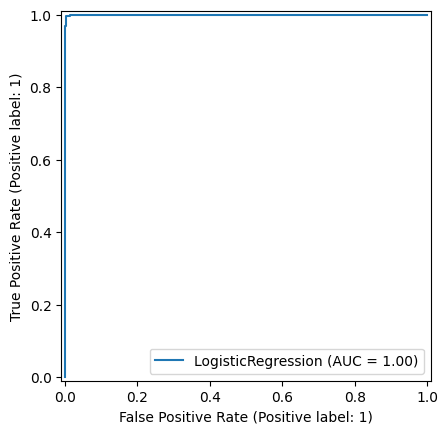

In [11]:
RocCurveDisplay.from_estimator(logictic_regression, X_test, y_test)

In [12]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       915
           1       0.99      1.00      0.99       280

    accuracy                           1.00      1195
   macro avg       0.99      1.00      1.00      1195
weighted avg       1.00      1.00      1.00      1195



In [13]:
correlations = X_train_bal.corrwith(y_train_bal).abs().sort_values(ascending=False)
print("Корреляции признаков с целевой переменной:")
print(correlations)

Корреляции признаков с целевой переменной:
chlorides               0.813942
total sulfur dioxide    0.793758
volatile acidity        0.691775
Unnamed: 0              0.632182
free sulfur dioxide     0.584197
sulphates               0.552178
residual sugar          0.498750
fixed acidity           0.491858
density                 0.485785
pH                      0.407583
quality                 0.258072
citric acid             0.217813
alcohol                 0.046508
dtype: float64


Смотря на количество ошибок 1 и 2 рода (3 и 1 соотвественно), можно сделать вывод, что модель очень хорошо справляется с класификацей предоствленных данных. На тренировочных данных сохраняется такое же низкое соотношение. Итого на 1192 приходятся 3 ошибки, то есть 0.25% приходятся на неверный прогноз. Рог кривая почти полностью соотвестует идеальной, что говорит о черезвучайно хорошой предсказательной силе данной модели, что даже немного странно. Модель работате практически идеально на предоставленных данных

In [14]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
knn = KNeighborsClassifier()
cv_res = cross_validate(knn, X_train_bal, y_train_bal, 
                        cv=10, scoring=['f1','accuracy','precision','recall'])
format_cv_table(cv_res, model_name=knn)

Результаты 10-Fold CV для KNeighborsClassifier():


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.940000,0.937200,0.896000,0.989100
1,0.950000,0.942600,0.901000,0.994500
2,0.950000,0.946700,0.903700,1.000000
3,0.960000,0.959000,0.924200,1.000000
4,0.950000,0.949500,0.908200,1.000000
5,0.950000,0.946700,0.903700,1.000000
6,0.950000,0.946700,0.903700,1.000000
7,0.940000,0.941300,0.894900,1.000000
8,0.960000,0.956300,0.919600,1.000000


F1           0.9500
Accuracy     0.9469
Precision    0.9052
Recall       0.9984
Name: Mean, dtype: float64

In [15]:
logictic_regression.fit(X_train_bal, y_train_bal) 

y_pred_train = logictic_regression.predict(X_train_bal)
y_pred_test = logictic_regression.predict(X_test)

print(accuracy_score(y_test, y_pred_test))

print(confusion_matrix(y_train_bal, y_pred_train))

0.9966527196652719
[[3648   12]
 [  14 3646]]


In [16]:
print(confusion_matrix(y_test, y_pred_test))

[[912   3]
 [  1 279]]


In [17]:
# 1. Создаем список моделей (можно добавить scaler внутрь пайплайна)
# Это полезно, если вы решите масштабировать данные
models = [
    ("LogisticRegression", Pipeline([('clf', LogisticRegression(random_state=42, max_iter=1000))])),
    ("KNN", Pipeline([('clf', KNeighborsClassifier())])),
    ("SVM", Pipeline([('clf', SVC())])),
]

# 2. Цикл для обучения и оценки
results = []

for name, pipeline in models:
    print(f"\n--- Обучение модели: {name} ---")
    # cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    # name = pipeline.(random_state=42, max_iter=1000)
    # cv_res = cross_validate(logictic_regression, X_train_bal, y_train_bal, 
    #                         cv=10, scoring=['f1','accuracy','precision','recall'])
    # format_cv_table(cv_res, model_name=name)
    
    # Обучение
    pipeline.fit(X_train_bal, y_train_bal)
    
    # Предсказание
    y_pred = pipeline.predict(X_test)
    
    # Вывод метрик (это происходит СРАЗУ ПОСЛЕ пайплайна)
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc})


results


--- Обучение модели: LogisticRegression ---
Confusion Matrix:
[[912   3]
 [  1 279]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       915
           1       0.99      1.00      0.99       280

    accuracy                           1.00      1195
   macro avg       0.99      1.00      1.00      1195
weighted avg       1.00      1.00      1.00      1195


--- Обучение модели: KNN ---
Confusion Matrix:
[[839  76]
 [  5 275]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95       915
           1       0.78      0.98      0.87       280

    accuracy                           0.93      1195
   macro avg       0.89      0.95      0.91      1195
weighted avg       0.94      0.93      0.93      1195


--- Обучение модели: SVM ---
Confusion Matrix:
[[617 298]
 [  0 280]]
Classification Report:
              precision    recall  f1-score   sup

[{'Model': 'LogisticRegression', 'Accuracy': 0.9966527196652719},
 {'Model': 'KNN', 'Accuracy': 0.9322175732217574},
 {'Model': 'SVM', 'Accuracy': 0.7506276150627615}]

In [18]:
model_pipeline = Pipeline_imb([
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_results = cross_validate(
    model_pipeline, 
    X_train, y_train,
    cv=cv, 
    scoring=['accuracy', 'f1', 'precision', 'recall']
)

format_cv_table(cv_results, model_name="LogReg Pipeline")

model_pipeline.fit(X_train, y_train) 
y_pred_test = model_pipeline.predict(X_test)

display(get_holdout_metrics(y_test, y_pred_test, 'LogisticRegression'))
RocCurveDisplay.from_estimator(model_pipeline, X_test, y_test)

KeyboardInterrupt: 

Результаты 10-Fold CV для Logistic Regression:


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.99,0.9937,0.9739,1.0000
1,1.00,0.9979,0.9912,1.0000
2,1.00,0.9979,0.9912,1.0000
3,1.00,0.9979,0.9912,1.0000
4,1.00,1.0000,1.0000,1.0000
5,0.98,0.9916,0.9821,0.9821
6,0.98,0.9916,0.9821,0.9821
7,0.99,0.9958,0.9911,0.9911
8,0.98,0.9916,0.9909,0.9732


,F1,Accuracy,Precision,Recall
Classifier,,,,
Logistic Regression,0.99,0.9967,0.9894,0.9964


[[912   3]
 [  1 279]]


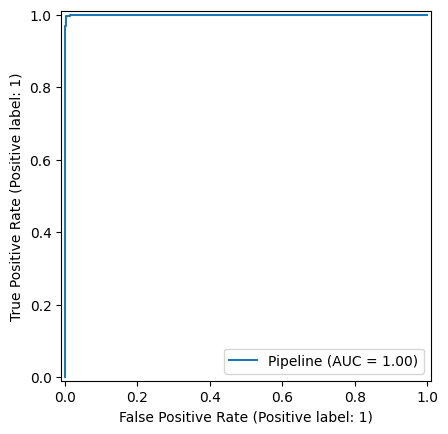

Результаты 10-Fold CV для kNN (k=5):


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.83,0.9038,0.7115,0.9911
1,0.86,0.9268,0.7655,0.9911
2,0.84,0.9142,0.7448,0.9643
3,0.82,0.8975,0.7006,0.9821
4,0.85,0.9184,0.7417,1.0000
5,0.81,0.8975,0.7086,0.9554
6,0.85,0.9205,0.7569,0.9732
7,0.89,0.9456,0.8209,0.9821
8,0.84,0.9163,0.7500,0.9643


,F1,Accuracy,Precision,Recall
Classifier,,,,
kNN (k=5),0.87,0.9322,0.7835,0.9821


[[839  76]
 [  5 275]]


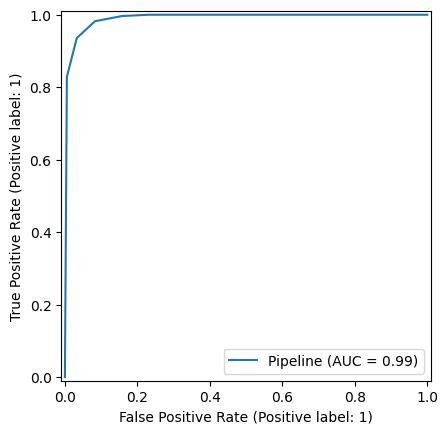

Результаты 10-Fold CV для Naive Bayes:


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.99,0.9937,0.9739,1.0000
1,0.99,0.9958,0.9911,0.9911
2,0.99,0.9958,0.9825,1.0000
3,1.00,0.9979,0.9912,1.0000
4,0.97,0.9854,0.9412,1.0000
5,0.98,0.9895,0.9735,0.9821
6,0.96,0.9833,0.9483,0.9821
7,0.99,0.9937,0.9823,0.9911
8,0.98,0.9895,0.9820,0.9732


,F1,Accuracy,Precision,Recall
Classifier,,,,
Naive Bayes,0.98,0.99,0.9653,0.9929


[[905  10]
 [  2 278]]


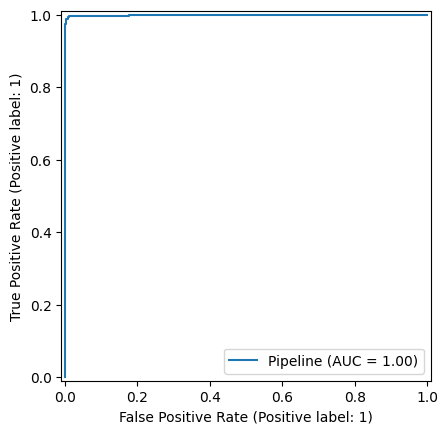

""


In [ ]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "kNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    # "SVM (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    # "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

holdout_results = pd.DataFrame()
cv_all_results = pd.DataFrame()

for name, model in classifiers.items():
    model_pipeline = Pipeline_imb([
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])

    cv_results = cross_validate(
        model_pipeline, 
        X_train, y_train,
        cv=cv, 
        scoring=['accuracy', 'f1', 'precision', 'recall']
    )
    
    model_pipeline.fit(X_train, y_train) 
    y_pred_test = model_pipeline.predict(X_test)

    cv_results = format_cv_table(cv_results, model_name=name)
    holdout_result = get_holdout_metrics(y_test, y_pred_test, name)
    print(confusion_matrix(y_test, y_pred_test))
    RocCurveDisplay.from_estimator(model_pipeline, X_test, y_test)
    plt.show()

holdout_results